Saving studyhub_cafe_dataset.csv to studyhub_cafe_dataset.csv
Dataset loaded: 5500 rows
  Booking_ID         Date_Time  Year  Month Day_of_Week  Hour Customer_ID  \
0    BK02840  02-01-2020 11:04  2020      1    Thursday    11       C1334   
1    BK04448  02-01-2020 12:21  2020      1    Thursday    12       C1015   
2    BK04414  02-01-2020 20:34  2020      1    Thursday    20       C0900   
3    BK00673  03-01-2020 16:41  2020      1      Friday    16       C1450   
4    BK02875  03-01-2020 20:11  2020      1      Friday    20       C0123   

          Customer_Type Booking_Type     Seat_Type  Duration_Hours  \
0    University Student      Walk-in  Private Room             2.5   
1    University Student      Walk-in    Individual             2.1   
2    University Student      Walk-in  Private Room             1.9   
3  Working Professional   Pre-Booked         Group             2.9   
4    University Student   Pre-Booked  Private Room             1.7   

   Total_Amount_MYR Payment_

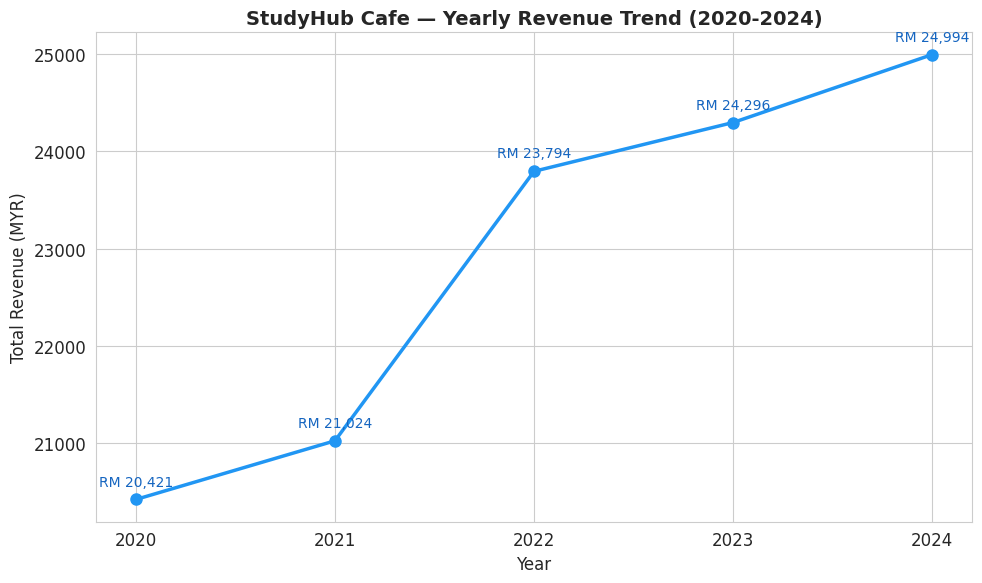

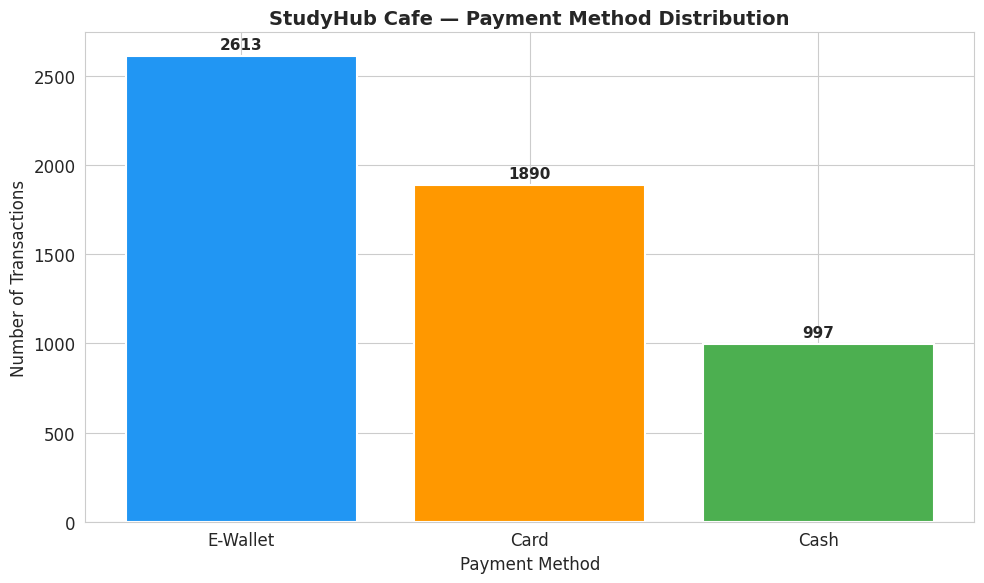

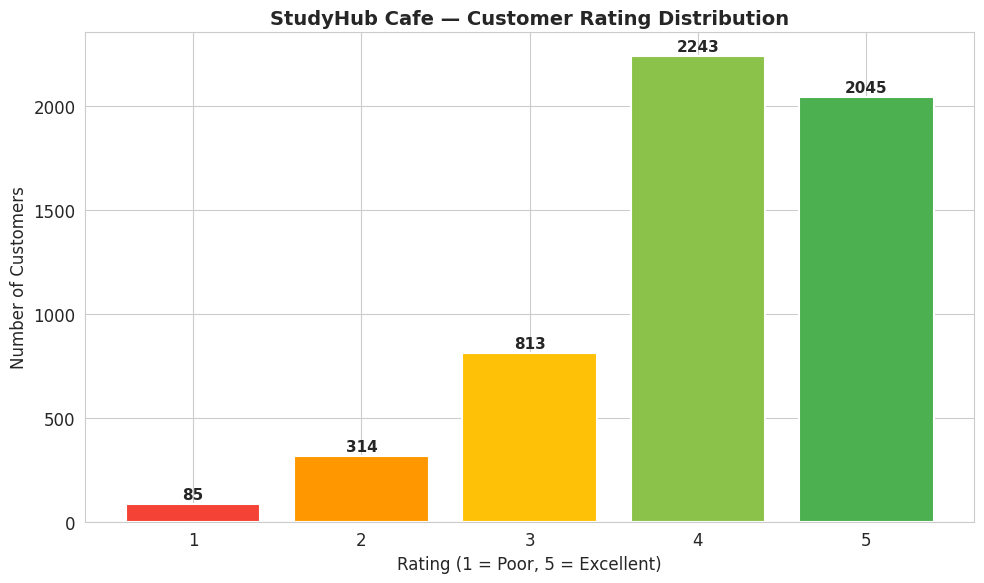

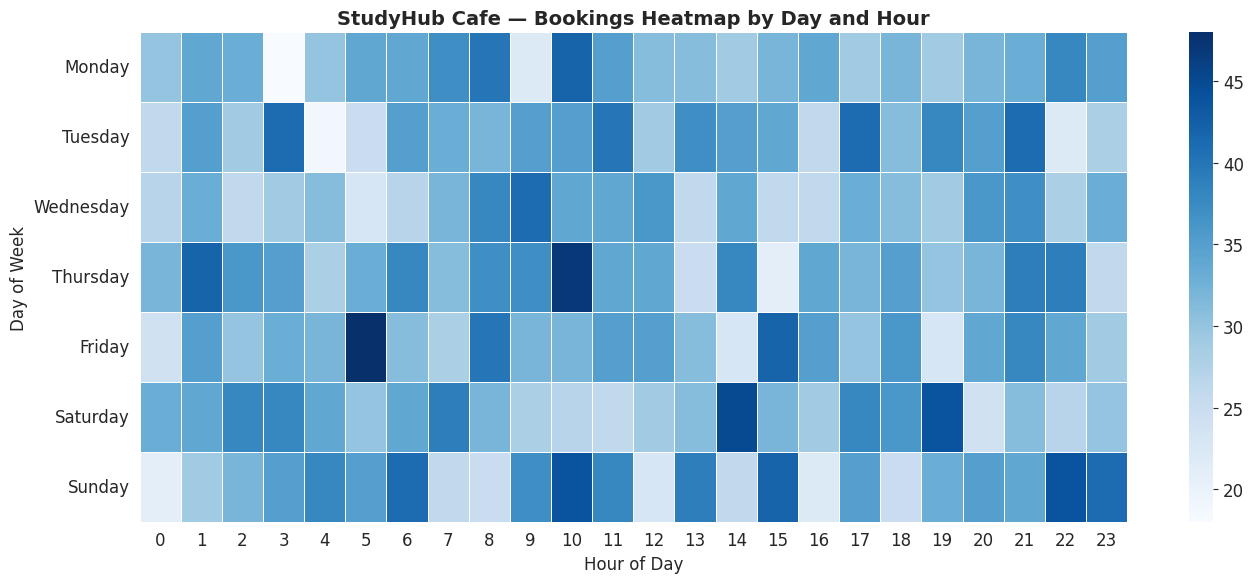

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
from google.colab import files
uploaded = files.upload()  # Upload your studyhub_cafe_dataset.csv here

df = pd.read_csv('studyhub_cafe_dataset.csv')
print(f"Dataset loaded: {len(df)} rows")
print(df.head())

# Set Style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# CHART 1 — Trend Chart (Line): Yearly Revenue Trend (2020-2024)
yearly_revenue = df.groupby('Year')['Total_Amount_MYR'].sum().reset_index()

plt.figure(figsize=(10, 6))
plt.plot(yearly_revenue['Year'], yearly_revenue['Total_Amount_MYR'],
         marker='o', linewidth=2.5, color='#2196F3', markersize=8)

50

# Add data labels on each point
for i, row in yearly_revenue.iterrows():
    plt.annotate(f"RM {row['Total_Amount_MYR']:,.0f}",
                 xy=(row['Year'], row['Total_Amount_MYR']),
                 xytext=(0, 10), textcoords='offset points',
                 ha='center', fontsize=10, color='#1565C0')

plt.title('StudyHub Cafe — Yearly Revenue Trend (2020-2024)', fontsize=14,
fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Revenue (MYR)', fontsize=12)
plt.xticks(yearly_revenue['Year'])
plt.tight_layout()
plt.savefig('chart1_yearly_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()

# CHART 2 — Comparison Chart (Bar): Payment Method Distribution
payment_counts = df['Payment_Method'].value_counts().reset_index()
payment_counts.columns = ['Payment_Method', 'Count']

colors = ['#2196F3', '#FF9800', '#4CAF50']
plt.figure(figsize=(10, 6))
bars = plt.bar(payment_counts['Payment_Method'], payment_counts['Count'],
               color=colors, edgecolor='white', linewidth=1.5)

# Add data labels on top of bars
for bar, count in zip(bars, payment_counts['Count']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(count), ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('StudyHub Cafe — Payment Method Distribution', fontsize=14, fontweight='bold')
51

plt.xlabel('Payment Method', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.tight_layout()
plt.savefig('chart2_payment_method.png', dpi=150, bbox_inches='tight')
plt.show()

# CHART 3 — Performance Chart (Bar): Customer Rating Distribution

rating_counts = df['Rating'].value_counts().sort_index().reset_index()
rating_counts.columns = ['Rating', 'Count']

colors_rating = ['#F44336', '#FF9800', '#FFC107', '#8BC34A', '#4CAF50']
plt.figure(figsize=(10, 6))
bars = plt.bar(rating_counts['Rating'], rating_counts['Count'],
               color=colors_rating, edgecolor='white', linewidth=1.5)

# Add data labels
for bar, count in zip(bars, rating_counts['Count']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(count), ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('StudyHub Cafe — Customer Rating Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Rating (1 = Poor, 5 = Excellent)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.savefig('chart3_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
# CHART 4 — Heatmap: Bookings by Day of Week and Hour
pivot = df.groupby(['Day_of_Week', 'Hour'])['Booking_ID'].count().unstack()
52


# Reorder days
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot = pivot.reindex(day_order)

plt.figure(figsize=(14, 6))
sns.heatmap(pivot, cmap='Blues', linewidths=0.5, annot=False)
plt.title('StudyHub Cafe — Bookings Heatmap by Day and Hour',
          fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Day of Week', fontsize=12)
plt.tight_layout()
plt.savefig('chart4_bookings_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# STUDYHUB CAFE — INTERACTIVE DASHBOARD (Plotly) — 4 CHARTS

import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Load dataset
from google.colab import files
uploaded = files.upload()  # Upload your studyhub_cafe_dataset.csv here

import io
df = pd.read_csv(io.BytesIO(list(uploaded.values())[0]))
print(f"Dataset loaded: {len(df)} rows")

# Prepare Data
yearly_revenue = df.groupby('Year')['Total_Amount_MYR'].sum().reset_index()

payment_counts = df['Payment_Method'].value_counts().reset_index()
payment_counts.columns = ['Payment_Method', 'Count']

rating_counts = df['Rating'].value_counts().sort_index().reset_index()
rating_counts.columns = ['Rating', 'Count']

booking_types = df['Booking_Type'].value_counts().reset_index()
booking_types.columns = ['Booking_Type', 'Count']

# Create Dashboard with 4 Charts
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'Yearly Revenue Trend (2020-2024)',
        'Payment Method Distribution',
        'Customer Rating Distribution',
        'Booking Type Distribution'
    ),
    specs=[
        [{"type": "scatter"}, {"type": "bar"}],
        [{"type": "bar"}, {"type": "pie"}]
    ]
)

# Chart 1 — Yearly Revenue Trend
fig.add_trace(
    go.Scatter(
        x=yearly_revenue['Year'],
        y=yearly_revenue['Total_Amount_MYR'],
        mode='lines+markers+text',
        text=[f"RM {v:,.0f}" for v in yearly_revenue['Total_Amount_MYR']],
        textposition='top center',
        line=dict(color='#2196F3', width=3),
        marker=dict(size=10)
    ),
    row=1, col=1
)

# Chart 2 — Payment Method
fig.add_trace(
    go.Bar(
        x=payment_counts['Payment_Method'],
        y=payment_counts['Count'],
        marker_color=['#2196F3', '#FF9800', '#4CAF50'],
        text=payment_counts['Count'],
        textposition='outside'
    ),
    row=1, col=2
)

# Chart 3 — Customer Rating
fig.add_trace(
    go.Bar(
        x=rating_counts['Rating'],
        y=rating_counts['Count'],
        marker_color=['#F44336','#FF9800','#FFC107','#8BC34A','#4CAF50'],
        text=rating_counts['Count'],
        textposition='outside'
    ),
    row=2, col=1
)

# Chart 4 — Booking Type
fig.add_trace(
    go.Pie(
        labels=booking_types['Booking_Type'],
        values=booking_types['Count'],
        hole=0.3,
        marker_colors=['#2196F3', '#FF9800']
    ),
    row=2, col=2
)

# Layout
fig.update_layout(
    title=dict(
        text='StudyHub Cafe — Big Data Analytics Dashboard',
        font=dict(size=20, color='#1565C0'),
        x=0.5
    ),
    height=800,
    showlegend=True,
    paper_bgcolor='white',
    plot_bgcolor='#f8f9fa',
    font=dict(size=11)
)

# Save Dashboard
fig.write_html('studyhub_dashboard.html')
fig.show()
print("Dashboard saved as studyhub_dashboard.html")

Saving studyhub_cafe_dataset.csv to studyhub_cafe_dataset (2).csv
Dataset loaded: 5500 rows


Dashboard saved as studyhub_dashboard.html


Saving studyhub_cafe_dataset.csv to studyhub_cafe_dataset (1).csv
Dataset Shape: (5500, 17)

First 5 rows:
  Booking_ID         Date_Time  Year  Month Day_of_Week  Hour Customer_ID  \
0    BK02840  02-01-2020 11:04  2020      1    Thursday    11       C1334   
1    BK04448  02-01-2020 12:21  2020      1    Thursday    12       C1015   
2    BK04414  02-01-2020 20:34  2020      1    Thursday    20       C0900   
3    BK00673  03-01-2020 16:41  2020      1      Friday    16       C1450   
4    BK02875  03-01-2020 20:11  2020      1      Friday    20       C0123   

          Customer_Type Booking_Type     Seat_Type  Duration_Hours  \
0    University Student      Walk-in  Private Room             2.5   
1    University Student      Walk-in    Individual             2.1   
2    University Student      Walk-in  Private Room             1.9   
3  Working Professional   Pre-Booked         Group             2.9   
4    University Student   Pre-Booked  Private Room             1.7   

   Total_

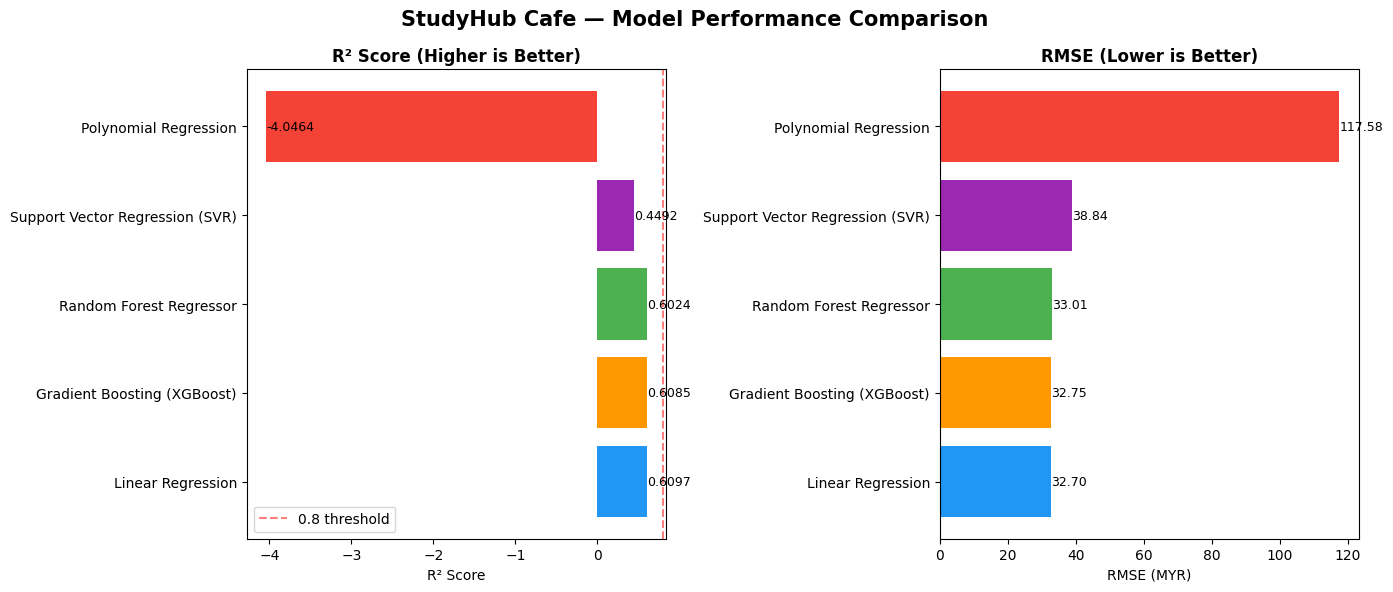

Saved: model_comparison.png


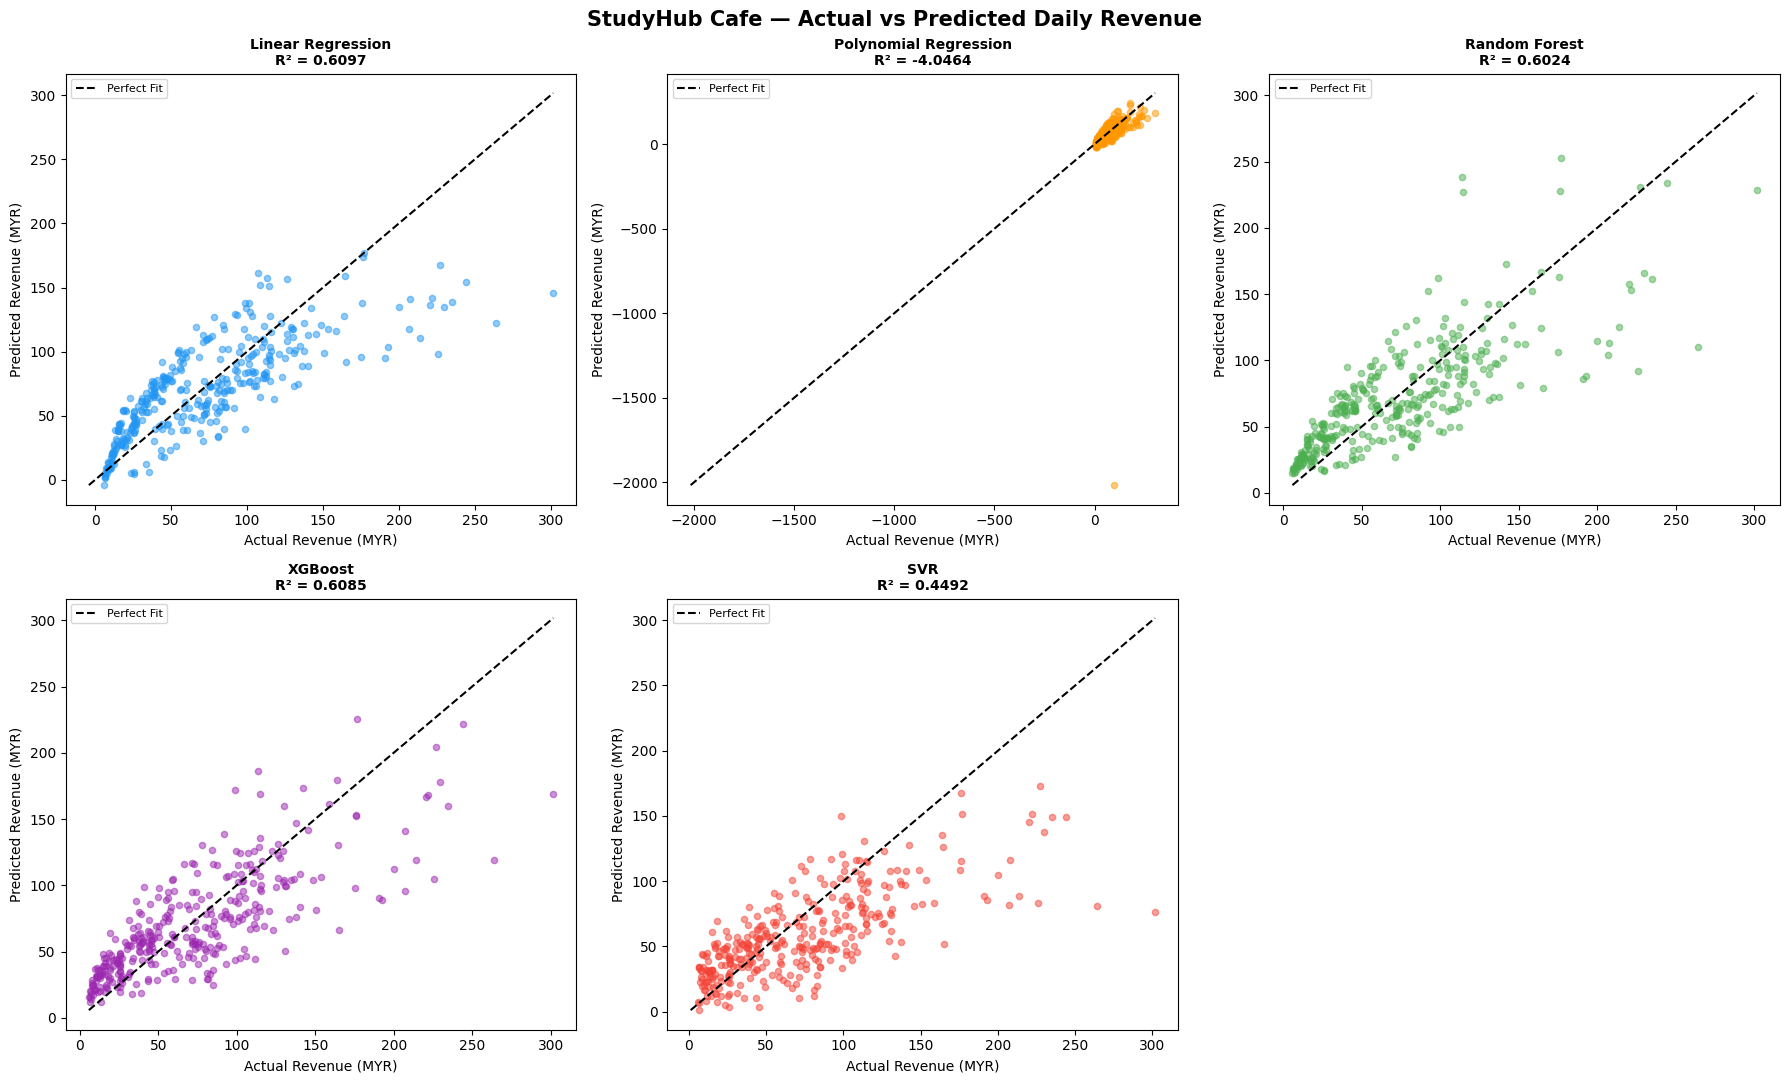

Saved: actual_vs_predicted.png


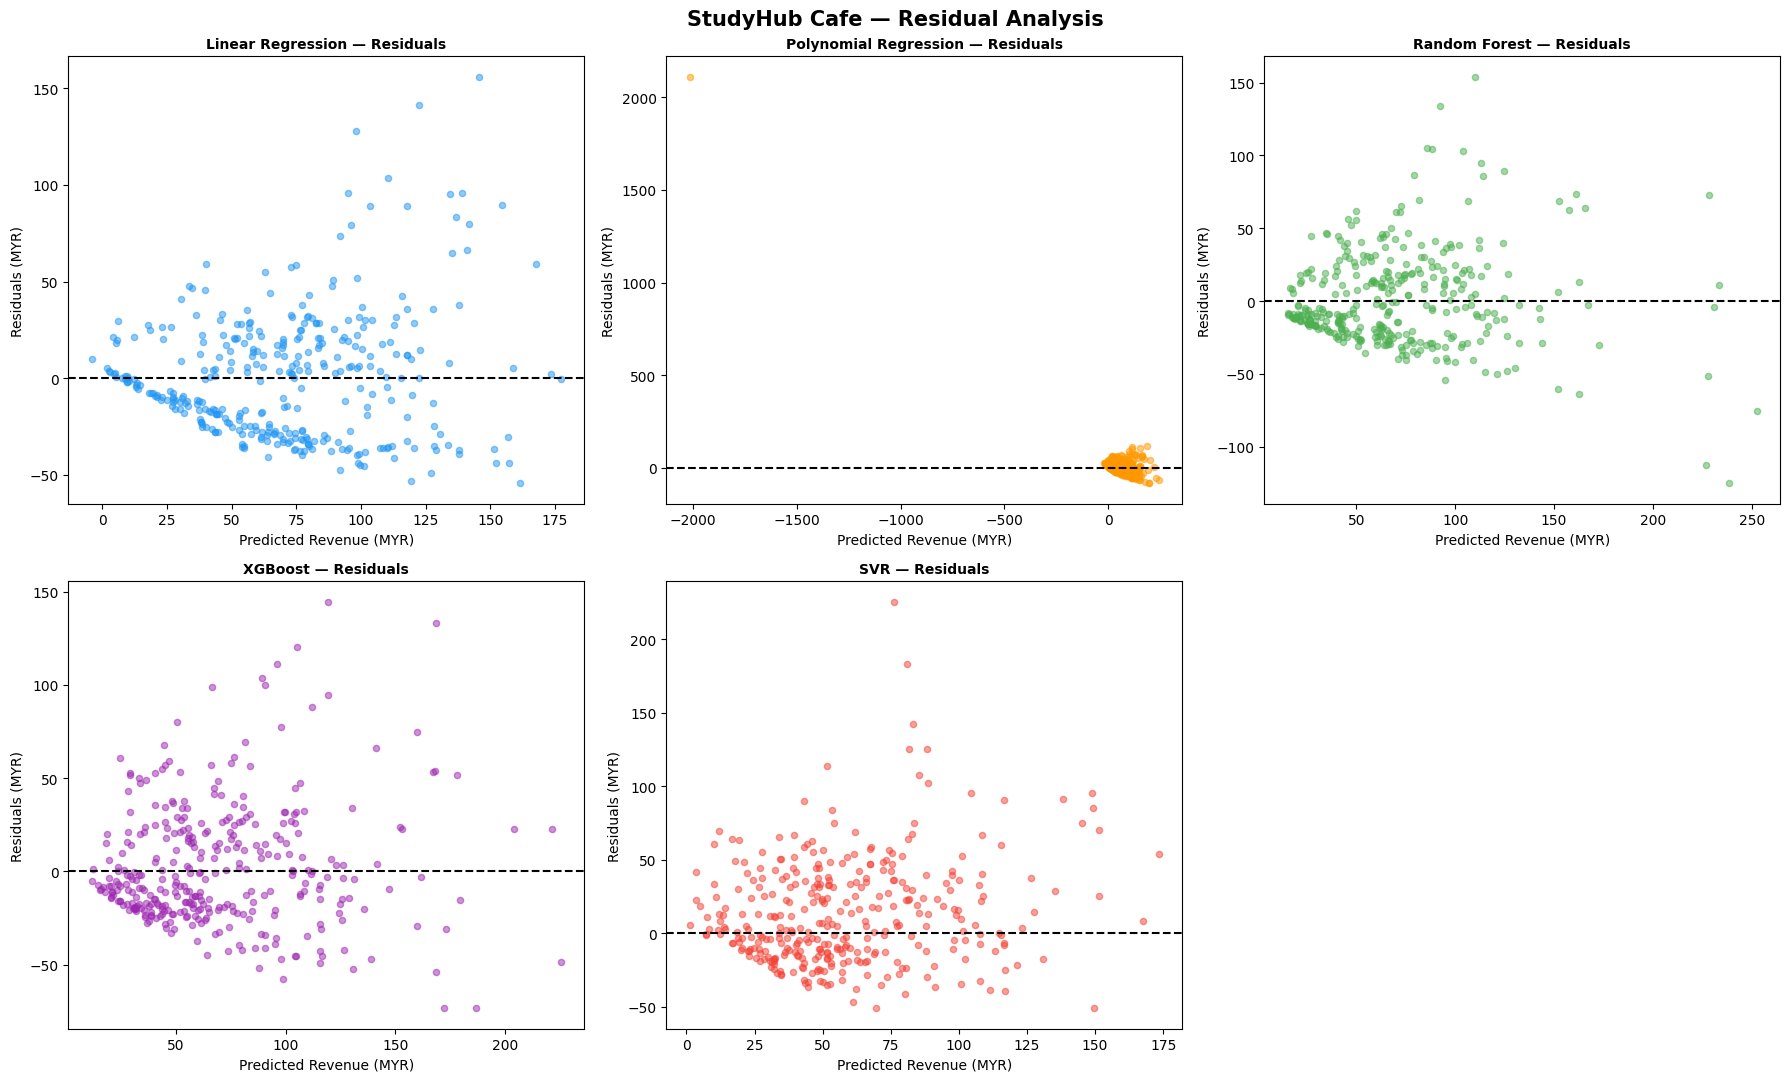

Saved: residual_analysis.png


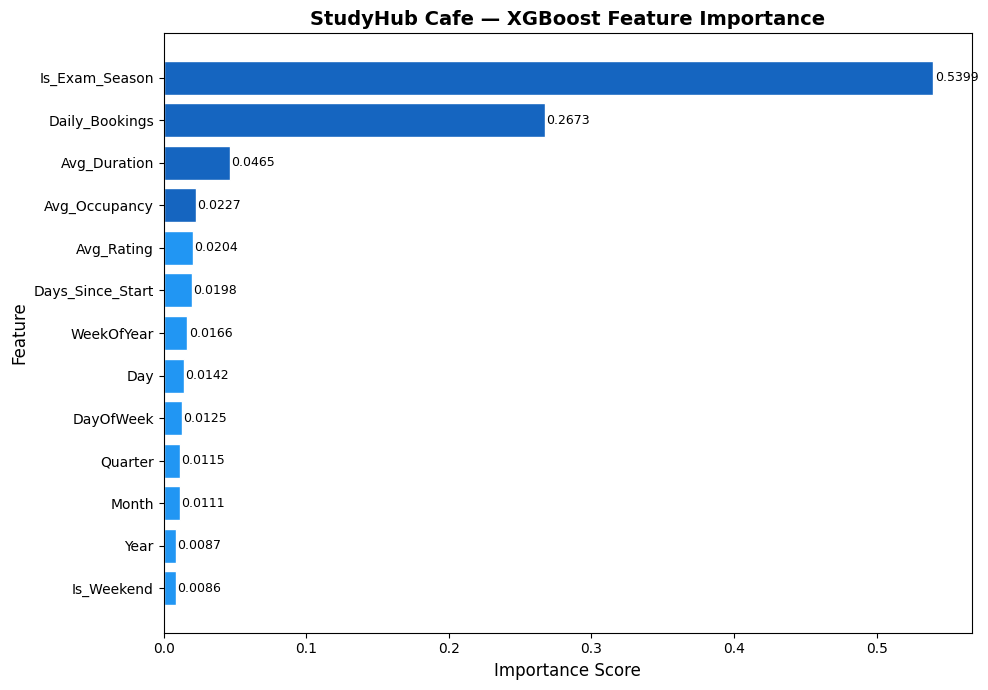

Saved: feature_importance_xgboost.png

>>> Generating 12-Month Future Forecast using XGBoost...

Monthly Revenue Forecast (Next 12 Months):
Month_Label  Predicted_Revenue
   Dec 2024          63.129696
   Jan 2025        1760.959229
   Feb 2025        1599.243530
   Mar 2025        1771.818848
   Apr 2025        1797.819336
   May 2025        2367.339844
   Jun 2025        2162.354004
   Jul 2025        1918.779053
   Aug 2025        1916.444580
   Sep 2025        1814.564697
   Oct 2025        2142.935059
   Nov 2025        2236.407715
   Dec 2025        1948.535767


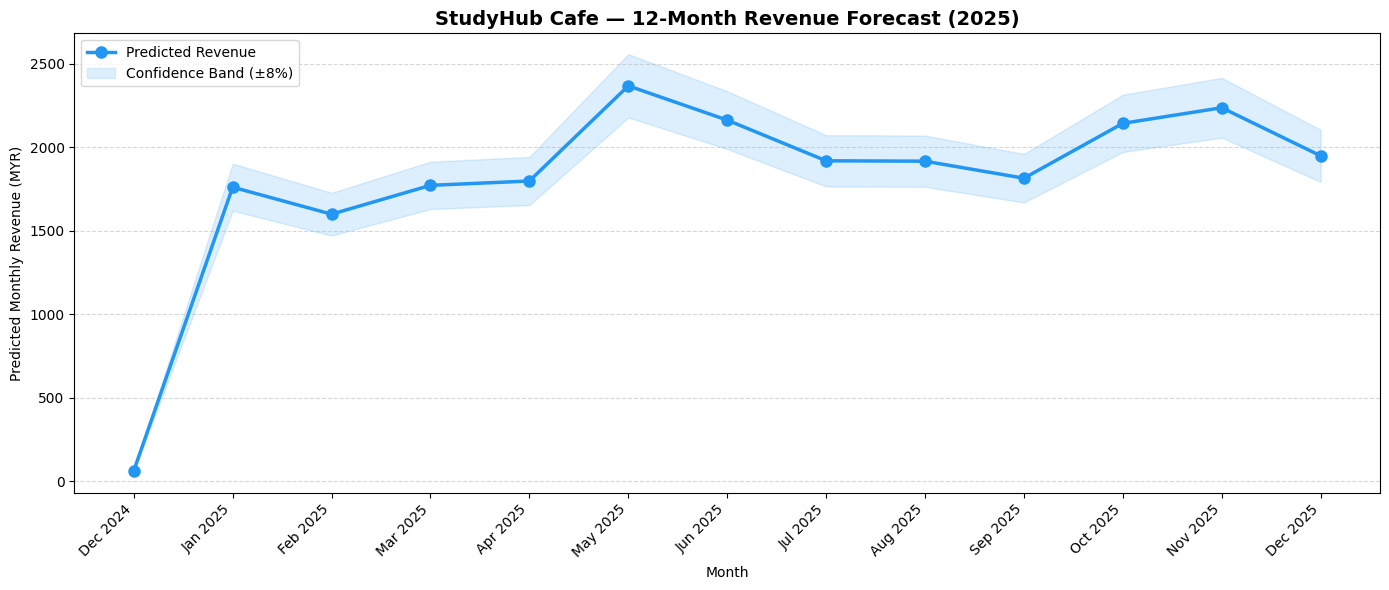

Saved: future_forecast.png

  FINAL SUMMARY — Component 7 Complete
  Target Variable  : Daily Revenue (Total_Amount_MYR)
  Dataset Size     : 1742 daily records
  Date Range       : 2020-01-02 to 2024-12-30
  Train / Test     : 1393 / 349 samples (80/20 split)
  Models Trained   : 5
  Best Model       : Linear Regression
  Best R² Score    : 0.6097
  Best RMSE        : 32.6979 MYR

  Charts saved:
  - model_comparison.png
  - actual_vs_predicted.png
  - residual_analysis.png
  - feature_importance_xgboost.png
  - future_forecast.png
                             Model        MAE           MSE        RMSE        R²
1                Linear Regression  25.028805   1069.152930   32.697904  0.609743
2      Gradient Boosting (XGBoost)  24.780810   1072.454053   32.748344  0.608538
3          Random Forest Regressor  25.036065   1089.379118   33.005744  0.602360
4  Support Vector Regression (SVR)  28.039099   1508.885954   38.844381  0.449233
5            Polynomial Regression  30.991806  1382

In [ ]:

# COMPONENT 7: Machine Learning Regression for Predictive Analytics
# StudyHub Cafe - Big Data Analytics Assignment
# Target Variable: Total_Amount_MYR (Daily Revenue)
# Models: Linear, Polynomial, Random Forest, XGBoost, SVR


#  STEP 1: INSTALL & IMPORT LIBRARIES
!pip install xgboost --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

#  STEP 2: LOAD DATASET
from google.colab import files
uploaded = files.upload()  # Upload studyhub_cafe_dataset.csv

import io
df = pd.read_csv(io.BytesIO(list(uploaded.values())[0]))

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

#  STEP 3: DATA PREPARATION
# FIX: Parse the existing Date_Time column — do NOT overwrite it
df['Date_Time'] = pd.to_datetime(df['Date_Time'], format='mixed', dayfirst=True)

# Aggregate to DAILY revenue
daily_df = df.groupby(df['Date_Time'].dt.date).agg(
    Daily_Revenue  = ('Total_Amount_MYR', 'sum'),
    Daily_Bookings = ('Total_Amount_MYR', 'count'),
    Avg_Duration   = ('Duration_Hours', 'mean'),
    Avg_Rating     = ('Rating', 'mean'),
    Avg_Occupancy  = ('Occupancy_Rate_%', 'mean')
).reset_index()

daily_df['Date_Time'] = pd.to_datetime(daily_df['Date_Time'])

print("\nDaily Dataset Shape:", daily_df.shape)
print(f"Date range: {daily_df['Date_Time'].min()} to {daily_df['Date_Time'].max()}")

#  STEP 4: FEATURE ENGINEERING
daily_df['Year']             = daily_df['Date_Time'].dt.year
daily_df['Month']            = daily_df['Date_Time'].dt.month
daily_df['Day']              = daily_df['Date_Time'].dt.day
daily_df['DayOfWeek']        = daily_df['Date_Time'].dt.dayofweek   # 0=Mon, 6=Sun
daily_df['Quarter']          = daily_df['Date_Time'].dt.quarter
daily_df['WeekOfYear']       = daily_df['Date_Time'].dt.isocalendar().week.astype(int)
daily_df['Is_Exam_Season']   = daily_df['Month'].isin([4, 5, 10, 11]).astype(int)
daily_df['Is_Weekend']       = (daily_df['DayOfWeek'] >= 5).astype(int)
daily_df['Days_Since_Start'] = (daily_df['Date_Time'] - daily_df['Date_Time'].min()).dt.days

print("\nEngineered Daily Dataset Shape:", daily_df.shape)
print(daily_df.head())

#  STEP 5: FEATURE SELECTION
features = [
    'Year', 'Month', 'Day', 'DayOfWeek', 'Quarter',
    'WeekOfYear', 'Is_Exam_Season', 'Is_Weekend',
    'Days_Since_Start', 'Daily_Bookings',
    'Avg_Duration', 'Avg_Rating', 'Avg_Occupancy'
]

X = daily_df[features]
y = daily_df['Daily_Revenue']

print("\nFeatures:", features)
print("Target  : Daily_Revenue")
print("X shape :", X.shape, "| y shape:", y.shape)

# STEP 6: TRAIN-TEST SPLIT (80-20)
# shuffle=False preserves time-series order
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

print(f"\nTraining samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")

#  STEP 7: FEATURE SCALING (for Linear, Poly, SVR only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

#  STEP 8: EVALUATION FUNCTION
def evaluate_model(name, y_test, y_pred):
    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  MSE  : {mse:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  R²   : {r2:.4f}")
    return {'Model': name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R²': r2}

results = []

# MODEL 1: LINEAR REGRESSION

print("\n>>> MODEL 1: Linear Regression")
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
results.append(evaluate_model("Linear Regression", y_test, y_pred_lr))


# MODEL 2: POLYNOMIAL REGRESSION (degree=2)

print("\n>>> MODEL 2: Polynomial Regression (degree=2)")
poly        = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly  = poly.transform(X_test_scaled)

pr = LinearRegression()
pr.fit(X_train_poly, y_train)
y_pred_pr = pr.predict(X_test_poly)
results.append(evaluate_model("Polynomial Regression", y_test, y_pred_pr))


# MODEL 3: RANDOM FOREST REGRESSOR

print("\n>>> MODEL 3: Random Forest Regressor")
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
results.append(evaluate_model("Random Forest Regressor", y_test, y_pred_rf))

# MODEL 4: GRADIENT BOOSTING (XGBoost)

print("\n>>> MODEL 4: Gradient Boosting (XGBoost)")
xgb_model = xgb.XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
results.append(evaluate_model("Gradient Boosting (XGBoost)", y_test, y_pred_xgb))


# MODEL 5: SUPPORT VECTOR REGRESSION (SVR)

print("\n>>> MODEL 5: Support Vector Regression (SVR)")
svr = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
svr.fit(X_train_scaled, y_train)
y_pred_svr = svr.predict(X_test_scaled)
results.append(evaluate_model("Support Vector Regression (SVR)", y_test, y_pred_svr))

#STEP 9: MODEL COMPARISON TABLE ─
print("\n\n" + "="*65)
print("  MODEL COMPARISON SUMMARY")
print("="*65)
results_df = pd.DataFrame(results).sort_values('R²', ascending=False).reset_index(drop=True)
results_df.index += 1
print(results_df.to_string())

best_model_name = results_df.iloc[0]['Model']
print(f"\nBEST MODEL: {best_model_name} (Highest R² Score)")

#  STEP 10: GRAPH 1 — Model Performance Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('StudyHub Cafe — Model Performance Comparison',
             fontsize=15, fontweight='bold')

bar_colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0', '#F44336']
models_list = results_df['Model']

# R² Score panel
axes[0].barh(models_list, results_df['R²'], color=bar_colors)
axes[0].set_title('R² Score (Higher is Better)', fontweight='bold')
axes[0].set_xlabel('R² Score')
axes[0].axvline(x=0.8, color='red', linestyle='--', alpha=0.5, label='0.8 threshold')
axes[0].legend()
for i, v in enumerate(results_df['R²']):
    axes[0].text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)

# RMSE panel
axes[1].barh(models_list, results_df['RMSE'], color=bar_colors)
axes[1].set_title('RMSE (Lower is Better)', fontweight='bold')
axes[1].set_xlabel('RMSE (MYR)')
for i, v in enumerate(results_df['RMSE']):
    axes[1].text(v + 0.1, i, f'{v:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_comparison.png")

# ── STEP 11: GRAPH 2 — Actual vs Predicted (All 5 Models) ───
preds  = [y_pred_lr, y_pred_pr, y_pred_rf, y_pred_xgb, y_pred_svr]
names  = ["Linear Regression", "Polynomial Regression",
          "Random Forest", "XGBoost", "SVR"]
plot_colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0', '#F44336']

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('StudyHub Cafe — Actual vs Predicted Daily Revenue',
             fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, (pred, name, color) in enumerate(zip(preds, names, plot_colors)):
    ax = axes[i]
    ax.scatter(y_test, pred, alpha=0.5, color=color, s=20)
    min_val = min(y_test.min(), pred.min())
    max_val = max(y_test.max(), pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=1.5, label='Perfect Fit')
    r2 = r2_score(y_test, pred)
    ax.set_title(f'{name}\nR² = {r2:.4f}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Actual Revenue (MYR)')
    ax.set_ylabel('Predicted Revenue (MYR)')
    ax.legend(fontsize=8)

axes[5].axis('off')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: actual_vs_predicted.png")

#  STEP 12: GRAPH 3 — Residual Analysis (All 5 Models)
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('StudyHub Cafe — Residual Analysis',
             fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, (pred, name, color) in enumerate(zip(preds, names, plot_colors)):
    residuals = y_test.values - pred
    ax = axes[i]
    ax.scatter(pred, residuals, alpha=0.5, color=color, s=20)
    ax.axhline(y=0, color='black', linestyle='--', lw=1.5)
    ax.set_title(f'{name} — Residuals', fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted Revenue (MYR)')
    ax.set_ylabel('Residuals (MYR)')

axes[5].axis('off')
plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: residual_analysis.png")

# STEP 13: GRAPH 4 — XGBoost Feature Importance
# FIX: Moved here AFTER all models are trained (was in wrong position before)
feature_importance = pd.DataFrame({
    'Feature'   : features,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 7))
fi_colors = ['#1565C0' if v >= feature_importance['Importance'].quantile(0.7)
             else '#2196F3' for v in feature_importance['Importance']]

bars = plt.barh(feature_importance['Feature'],
                feature_importance['Importance'],
                color=fi_colors, edgecolor='white')

for bar, val in zip(bars, feature_importance['Importance']):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)

plt.title('StudyHub Cafe — XGBoost Feature Importance',
          fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.savefig('feature_importance_xgboost.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: feature_importance_xgboost.png")

#  STEP 14: GRAPH 5 — 12-Month Future Forecast (XGBoost)
# FIX: Uses XGBoost (best model) — was incorrectly using Random Forest before
print("\n>>> Generating 12-Month Future Forecast using XGBoost...")

last_date    = daily_df['Date_Time'].max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=365, freq='D')

future_df = pd.DataFrame({'Date_Time': future_dates})
future_df['Year']             = future_df['Date_Time'].dt.year
future_df['Month']            = future_df['Date_Time'].dt.month
future_df['Day']              = future_df['Date_Time'].dt.day
future_df['DayOfWeek']        = future_df['Date_Time'].dt.dayofweek
future_df['Quarter']          = future_df['Date_Time'].dt.quarter
future_df['WeekOfYear']       = future_df['Date_Time'].dt.isocalendar().week.astype(int)
future_df['Is_Exam_Season']   = future_df['Month'].isin([4, 5, 10, 11]).astype(int)
future_df['Is_Weekend']       = (future_df['DayOfWeek'] >= 5).astype(int)
future_df['Days_Since_Start'] = (future_df['Date_Time'] - daily_df['Date_Time'].min()).dt.days

# Fill aggregated features using last 90 days of actual data
recent = daily_df.tail(90)
future_df['Daily_Bookings'] = recent['Daily_Bookings'].mean()
future_df['Avg_Duration']   = recent['Avg_Duration'].mean()
future_df['Avg_Rating']     = recent['Avg_Rating'].mean()
future_df['Avg_Occupancy']  = recent['Avg_Occupancy'].mean()

# FIX: Predict using XGBoost (not Random Forest)
future_df['Predicted_Revenue'] = xgb_model.predict(future_df[features])

# Aggregate to monthly
monthly_forecast = future_df.groupby(['Year', 'Month'])['Predicted_Revenue'].sum().reset_index()
monthly_forecast['Month_Label'] = monthly_forecast.apply(
    lambda r: pd.Timestamp(year=int(r['Year']), month=int(r['Month']), day=1).strftime('%b %Y'),
    axis=1
)

print("\nMonthly Revenue Forecast (Next 12 Months):")
print(monthly_forecast[['Month_Label', 'Predicted_Revenue']].to_string(index=False))

plt.figure(figsize=(14, 6))
plt.plot(monthly_forecast['Month_Label'],
         monthly_forecast['Predicted_Revenue'],
         marker='o', color='#2196F3', linewidth=2.5,
         markersize=8, label='Predicted Revenue')
plt.fill_between(range(len(monthly_forecast)),
                 monthly_forecast['Predicted_Revenue'] * 0.92,
                 monthly_forecast['Predicted_Revenue'] * 1.08,
                 alpha=0.15, color='#2196F3', label='Confidence Band (±8%)')
plt.xticks(range(len(monthly_forecast)),
           monthly_forecast['Month_Label'], rotation=45, ha='right')
plt.title('StudyHub Cafe — 12-Month Revenue Forecast (2025)',
          fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Predicted Monthly Revenue (MYR)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('future_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: future_forecast.png")

#  STEP 15: FINAL SUMMARY
print("\n" + "="*65)
print("  FINAL SUMMARY — Component 7 Complete")
print("="*65)
print(f"  Target Variable  : Daily Revenue (Total_Amount_MYR)")
print(f"  Dataset Size     : {len(daily_df)} daily records")
print(f"  Date Range       : {daily_df['Date_Time'].min().date()} to {daily_df['Date_Time'].max().date()}")
print(f"  Train / Test     : {len(X_train)} / {len(X_test)} samples (80/20 split)")
print(f"  Models Trained   : 5")
print(f"  Best Model       : {best_model_name}")
print(f"  Best R² Score    : {results_df.iloc[0]['R²']:.4f}")
print(f"  Best RMSE        : {results_df.iloc[0]['RMSE']:.4f} MYR")
print("\n  Charts saved:")
print("  - model_comparison.png")
print("  - actual_vs_predicted.png")
print("  - residual_analysis.png")
print("  - feature_importance_xgboost.png")
print("  - future_forecast.png")
print("="*65)
print(results_df[['Model', 'MAE', 'MSE', 'RMSE', 'R²']].to_string())

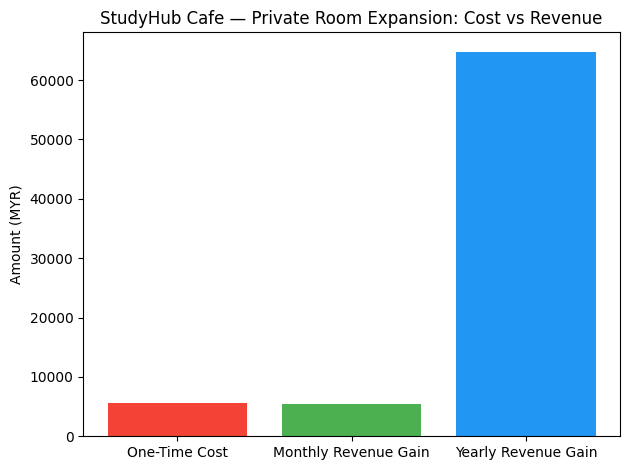

In [ ]:
import matplotlib.pyplot as plt

categories = ['One-Time Cost', 'Monthly Revenue Gain', 'Yearly Revenue Gain']
values = [5600, 5400, 64800]
colors = ['#F44336', '#4CAF50', '#2196F3']

plt.bar(categories, values, color=colors)
plt.title('StudyHub Cafe — Private Room Expansion: Cost vs Revenue')
plt.ylabel('Amount (MYR)')
plt.tight_layout()
plt.show()
